In [1]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

ERROR! Session/line number was not unique in database. History logging moved to new session 141


In [2]:
# -------------------------------------------------
# UTILITY: FIND LAST CONV LAYER
# -------------------------------------------------
def get_last_conv_layer(model):
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            return layer.name
    raise ValueError("No Conv2D layer found")

# -------------------------------------------------
# UTILITY: FORWARD PASS UP TO TARGET LAYER
# Manually runs each layer and captures the conv output.
# This completely avoids model.input / model.output.
# -------------------------------------------------
def get_conv_output_and_prediction(model, img_tensor, layer_name):
    """
    Manually walks through model.layers, captures the output
    at `layer_name`, and returns (conv_output, final_prediction).
    Works on any Sequential model in Keras 3 without needing
    model.input or model.output.
    """
    x = img_tensor
    conv_output = None

    for layer in model.layers:
        x = layer(x, training=False)
        if layer.name == layer_name:
            conv_output = x  # Capture intermediate output here

    if conv_output is None:
        raise ValueError(f"Layer '{layer_name}' not found during forward pass.")

    return conv_output, x  # x is now the final prediction

# -------------------------------------------------
# GRAD-CAM
# -------------------------------------------------
def grad_cam(model, img_array, layer_name):
    img_tensor = tf.cast(img_array, tf.float32)

    with tf.GradientTape() as tape:
        tape.watch(img_tensor)
        conv_output, predictions = get_conv_output_and_prediction(
            model, img_tensor, layer_name
        )
        tape.watch(conv_output)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_output)

    if grads is None:
        print("  [Warning] Grad-CAM: gradients are None, returning blank heatmap.")
        h, w = conv_output.shape[1], conv_output.shape[2]
        return np.zeros((h, w))

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))  # (C,)
    conv_out_val = conv_output[0]                          # (H, W, C)

    heatmap = conv_out_val @ pooled_grads[..., tf.newaxis] # (H, W, 1)
    heatmap = tf.squeeze(heatmap)                          # (H, W)
    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

# -------------------------------------------------
# GRAD-CAM++
# -------------------------------------------------
def grad_cam_plus(model, img_array, layer_name):
    img_tensor = tf.cast(img_array, tf.float32)

    with tf.GradientTape() as tape:
        tape.watch(img_tensor)
        conv_output, predictions = get_conv_output_and_prediction(
            model, img_tensor, layer_name
        )
        tape.watch(conv_output)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_output)

    if grads is None:
        print("  [Warning] Grad-CAM++: gradients are None, returning blank heatmap.")
        h, w = conv_output.shape[1], conv_output.shape[2]
        return np.zeros((h, w))

    grads_power_2 = grads ** 2
    grads_power_3 = grads ** 3

    conv_out_val = conv_output[0]                          # (H, W, C)

    # Global spatial sum of activations for denominator
    global_sum = tf.reduce_sum(conv_out_val, axis=(0, 1))  # (C,)

    denominator = (
        2.0 * grads_power_2
        + grads_power_3 * global_sum[tf.newaxis, tf.newaxis, tf.newaxis, :]
    )
    denominator = tf.where(
        tf.equal(denominator, 0),
        tf.ones_like(denominator),
        denominator
    )

    alphas = grads_power_2 / denominator                   # (1, H, W, C)
    relu_grads = tf.maximum(grads, 0)                      # (1, H, W, C)
    weights = tf.reduce_sum(relu_grads * alphas, axis=(1, 2))[0]  # (C,)

    heatmap = tf.reduce_sum(weights * conv_out_val, axis=-1)  # (H, W)
    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

# -------------------------------------------------
# SCORE-CAM (Optimized — no model.input needed)
# -------------------------------------------------
def score_cam(model, img_array, layer_name):
    img_tensor = tf.cast(img_array, tf.float32)

    # Get activations at the target layer via manual forward pass
    _, _ = get_conv_output_and_prediction(model, img_tensor, layer_name)

    # Re-run to capture numpy activations
    x = img_tensor
    for layer in model.layers:
        x = layer(x, training=False)
        if layer.name == layer_name:
            activations = x.numpy()[0]  # (H, W, C)
            break

    input_h, input_w = img_array.shape[1], img_array.shape[2]
    heatmap = np.zeros(activations.shape[:2])

    for i in range(activations.shape[-1]):
        act_map = activations[:, :, i]
        if np.max(act_map) <= 0:
            continue

        act_map_resized = cv2.resize(act_map, (input_w, input_h))
        act_min, act_max = act_map_resized.min(), act_map_resized.max()
        act_map_norm = (act_map_resized - act_min) / (act_max - act_min + 1e-8)

        masked_img = (img_array[0] * act_map_norm[..., np.newaxis]).astype(np.float32)
        masked_tensor = tf.constant(np.expand_dims(masked_img, axis=0))

        # Full forward pass on masked image
        pred_x = masked_tensor
        for layer in model.layers:
            pred_x = layer(pred_x, training=False)
        pred = pred_x.numpy()[0][0]

        heatmap += pred * act_map_resized

    heatmap = np.maximum(heatmap, 0)
    if heatmap.max() > 0:
        heatmap /= heatmap.max()
    return heatmap

# -------------------------------------------------
# MAIN ENSEMBLE PIPELINE
# -------------------------------------------------
def ensemble_explain(model_paths, image_path):
    original_img = cv2.imread(image_path)
    if original_img is None:
        raise ValueError(f"Image not found at: {image_path}")

    original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB)
    img_res = cv2.resize(original_img, (224, 224))
    img_array = np.expand_dims(img_res / 255.0, axis=0).astype(np.float32)

    final_heatmap = np.zeros((224, 224))
    predictions = []

    print(f"Processing {len(model_paths)} ensemble model(s)...\n")

    for path in model_paths:
        print(f"--- Loading: {path} ---")
        model = tf.keras.models.load_model(path, compile=False)

        layer_name = get_last_conv_layer(model)
        print(f"  Last Conv Layer: {layer_name}")

        # Prediction via manual forward pass — no .output needed
        img_tensor = tf.cast(img_array, tf.float32)
        _, pred_tensor = get_conv_output_and_prediction(model, img_tensor, layer_name)
        pred = float(pred_tensor.numpy()[0][0])
        predictions.append(pred)
        print(f"  Raw prediction: {pred:.4f}")

        print("  Generating Grad-CAM...")
        c1 = grad_cam(model, img_array, layer_name)

        print("  Generating Grad-CAM++...")
        c2 = grad_cam_plus(model, img_array, layer_name)

        # Optional — uncomment to add Score-CAM (slow):
        # print("  Generating Score-CAM...")
        # c3 = score_cam(model, img_array, layer_name)
        # model_cam = (c1 + c2 + c3) / 3

        model_cam = (c1 + c2) / 2
        model_cam_res = cv2.resize(model_cam, (224, 224))
        final_heatmap += model_cam_res
        print()

    final_heatmap /= len(model_paths)
    avg_prediction = float(np.mean(predictions))
    print(f"✅ Done. Ensemble avg prediction: {avg_prediction:.4f}")

    return final_heatmap, img_res, avg_prediction

# -------------------------------------------------
# PLOT RESULTS
# -------------------------------------------------
def plot_result(heatmap, img, prediction):
    heatmap_uint8 = np.uint8(255 * heatmap)
    heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

    overlay = cv2.addWeighted(img, 0.6, heatmap_color, 0.4, 0)
    status = "Osteoporosis Detected" if prediction > 0.4 else "Normal"

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.title("Input X-Ray")
    plt.imshow(img)
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.title("Ensemble Saliency Map")
    plt.imshow(heatmap, cmap="jet")
    plt.colorbar()
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.title(f"Diagnostic Result: {status}\nConfidence: {prediction:.2f}")
    plt.imshow(overlay)
    plt.axis("off")

    plt.tight_layout()
    plt.savefig("ensemble_result.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: ensemble_result.png")


Processing 5 ensemble model(s)...

--- Loading: cnn_model_0.h5 ---
  Last Conv Layer: conv2d_26
  Raw prediction: 0.5519
  Generating Grad-CAM...
  Generating Grad-CAM++...

--- Loading: cnn_model_1.h5 ---
  Last Conv Layer: conv2d_35
  Raw prediction: 0.0310
  Generating Grad-CAM...
  Generating Grad-CAM++...

--- Loading: cnn_model_2.h5 ---
  Last Conv Layer: conv2d_44
  Raw prediction: 0.0103
  Generating Grad-CAM...
  Generating Grad-CAM++...

--- Loading: cnn_model_3.h5 ---
  Last Conv Layer: conv2d_53
  Raw prediction: 0.0007
  Generating Grad-CAM...
  Generating Grad-CAM++...

--- Loading: cnn_model_4.h5 ---
  Last Conv Layer: conv2d_62
  Raw prediction: 0.2762
  Generating Grad-CAM...
  Generating Grad-CAM++...

✅ Done. Ensemble avg prediction: 0.1740


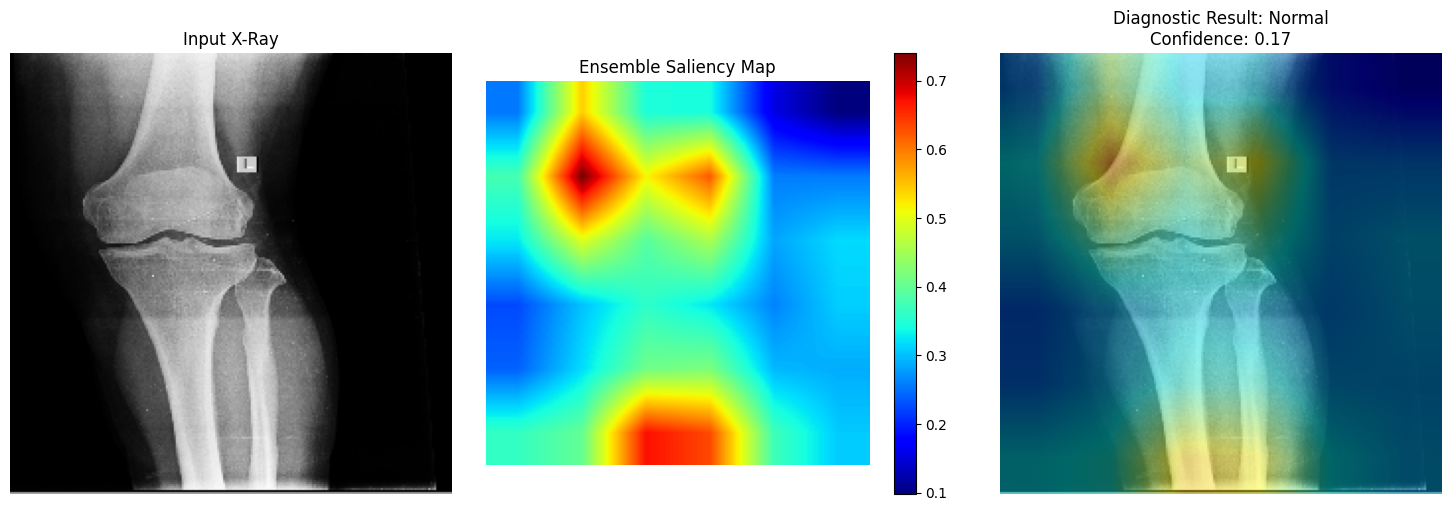

Saved: ensemble_result.png


In [3]:
# -------------------------------------------------
# EXECUTION
# -------------------------------------------------
model_files = [f"cnn_model_{i}.h5" for i in range(5)]
test_image = r"C:\Users\jaina\OneDrive\Desktop\Major P\OSP\dataset\normal\normal_0035.png"

try:
    heatmap, img, pred = ensemble_explain(model_files, test_image)
    plot_result(heatmap, img, pred)
except Exception as e:
    import traceback
    traceback.print_exc()
    print(f"\nError: {e}")

Processing 5 ensemble model(s)...

--- Loading: cnn_model_0.h5 ---
  Last Conv Layer: conv2d_26
  Raw prediction: 0.9987
  Generating Grad-CAM...
  Generating Grad-CAM++...

--- Loading: cnn_model_1.h5 ---
  Last Conv Layer: conv2d_35
  Raw prediction: 0.9983
  Generating Grad-CAM...
  Generating Grad-CAM++...

--- Loading: cnn_model_2.h5 ---
  Last Conv Layer: conv2d_44
  Raw prediction: 0.9992
  Generating Grad-CAM...
  Generating Grad-CAM++...

--- Loading: cnn_model_3.h5 ---
  Last Conv Layer: conv2d_53
  Raw prediction: 0.9978
  Generating Grad-CAM...
  Generating Grad-CAM++...

--- Loading: cnn_model_4.h5 ---
  Last Conv Layer: conv2d_62
  Raw prediction: 0.9990
  Generating Grad-CAM...
  Generating Grad-CAM++...

✅ Done. Ensemble avg prediction: 0.9986


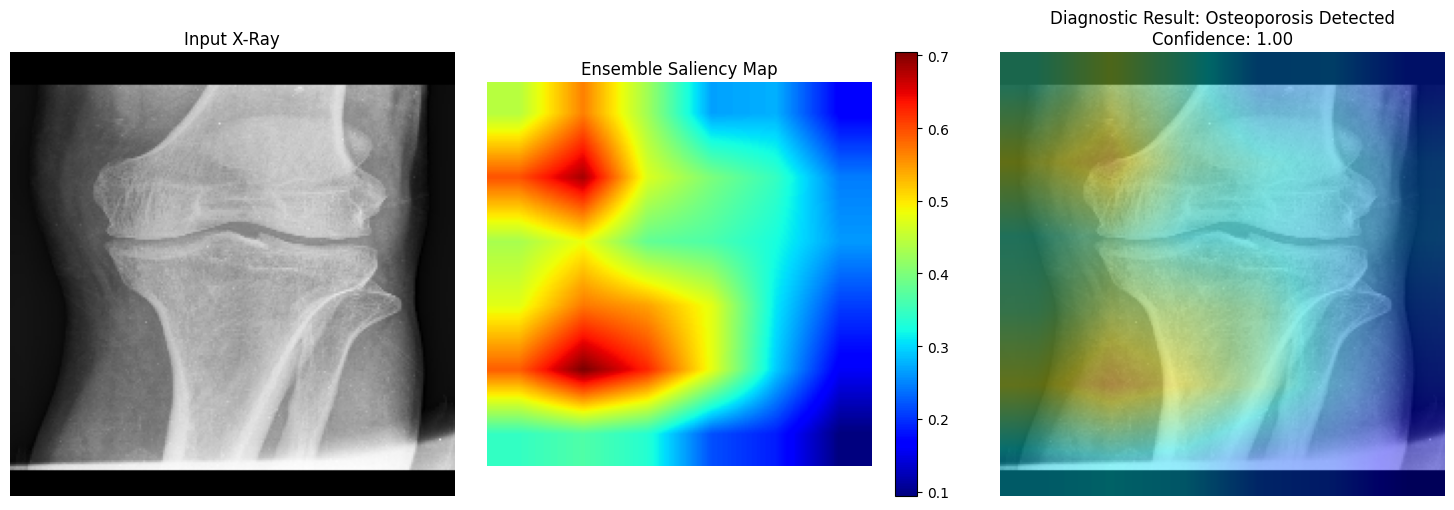

Saved: ensemble_result.png


In [4]:
# -------------------------------------------------
# EXECUTION
# -------------------------------------------------
model_files = [f"cnn_model_{i}.h5" for i in range(5)]
test_image = r"C:\Users\jaina\OneDrive\Desktop\Major P\OSP\dataset\osteoporosis\osteoporosis_0015.png"

try:
    heatmap, img, pred = ensemble_explain(model_files, test_image)
    plot_result(heatmap, img, pred)
except Exception as e:
    import traceback
    traceback.print_exc()
    print(f"\nError: {e}")

Processing 5 ensemble model(s)...

--- Loading: cnn_model_0.h5 ---
  Last Conv Layer: conv2d_26
  Raw prediction: 0.0006
  Generating Grad-CAM...
  Generating Grad-CAM++...

--- Loading: cnn_model_1.h5 ---
  Last Conv Layer: conv2d_35
  Raw prediction: 0.0010
  Generating Grad-CAM...
  Generating Grad-CAM++...

--- Loading: cnn_model_2.h5 ---
  Last Conv Layer: conv2d_44
  Raw prediction: 0.0167
  Generating Grad-CAM...
  Generating Grad-CAM++...

--- Loading: cnn_model_3.h5 ---
  Last Conv Layer: conv2d_53
  Raw prediction: 0.0002
  Generating Grad-CAM...
  Generating Grad-CAM++...

--- Loading: cnn_model_4.h5 ---
  Last Conv Layer: conv2d_62
  Raw prediction: 0.0014
  Generating Grad-CAM...
  Generating Grad-CAM++...

✅ Done. Ensemble avg prediction: 0.0040


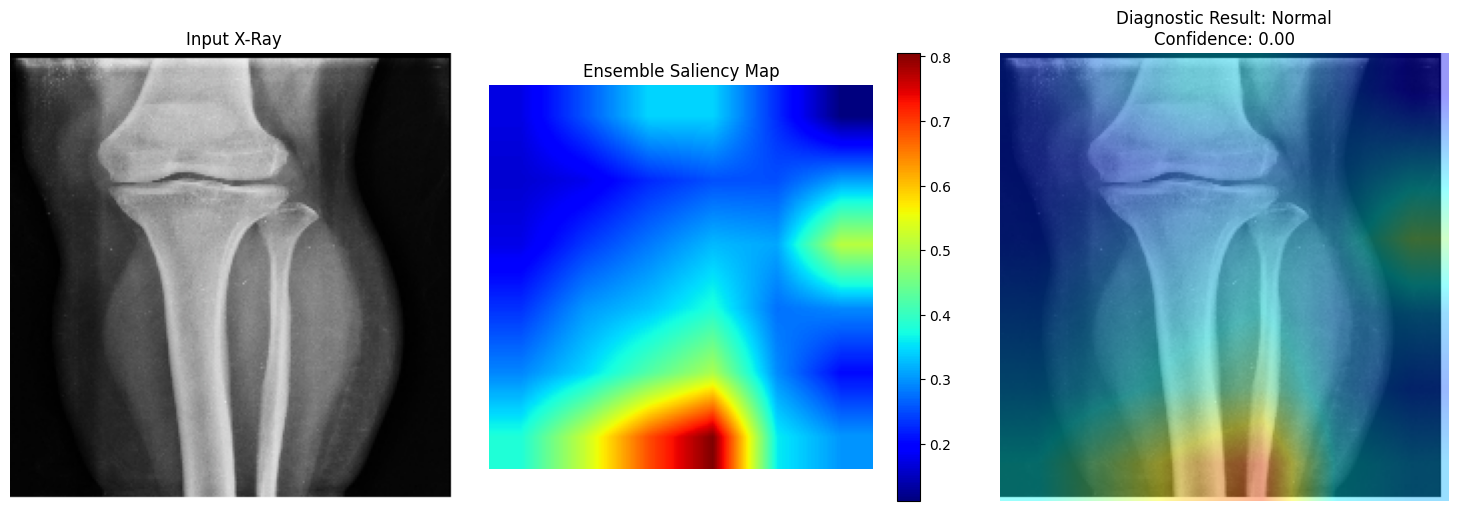

Saved: ensemble_result.png

Error: Image not found at: C:\Users\jaina\OneDrive\Desktop\Major P\OSP\dataset\normal\normal_0031.png
Processing 5 ensemble model(s)...

--- Loading: cnn_model_0.h5 ---


Traceback (most recent call last):
  File "C:\Users\jaina\AppData\Local\Temp\ipykernel_10016\2208283588.py", line 9, in <module>
    heatmap, img, pred = ensemble_explain(model_files, test_image)
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\jaina\AppData\Local\Temp\ipykernel_10016\784608617.py", line 164, in ensemble_explain
    raise ValueError(f"Image not found at: {image_path}")
ValueError: Image not found at: C:\Users\jaina\OneDrive\Desktop\Major P\OSP\dataset\normal\normal_0031.png


  Last Conv Layer: conv2d_26
  Raw prediction: 0.0728
  Generating Grad-CAM...
  Generating Grad-CAM++...

--- Loading: cnn_model_1.h5 ---
  Last Conv Layer: conv2d_35
  Raw prediction: 0.0121
  Generating Grad-CAM...
  Generating Grad-CAM++...

--- Loading: cnn_model_2.h5 ---
  Last Conv Layer: conv2d_44
  Raw prediction: 0.0832
  Generating Grad-CAM...
  Generating Grad-CAM++...

--- Loading: cnn_model_3.h5 ---
  Last Conv Layer: conv2d_53
  Raw prediction: 0.0012
  Generating Grad-CAM...
  Generating Grad-CAM++...

--- Loading: cnn_model_4.h5 ---
  Last Conv Layer: conv2d_62
  Raw prediction: 0.0424
  Generating Grad-CAM...
  Generating Grad-CAM++...

✅ Done. Ensemble avg prediction: 0.0423


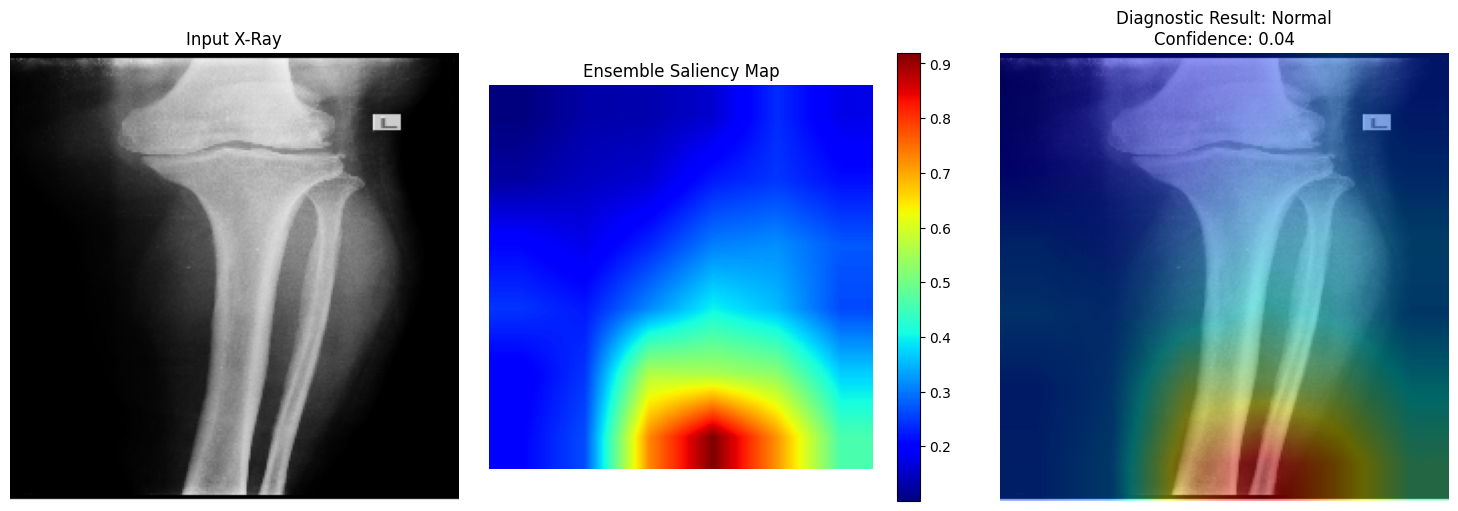

Saved: ensemble_result.png

Error: Image not found at: C:\Users\jaina\OneDrive\Desktop\Major P\OSP\dataset\normal\normal_0033.png
Processing 5 ensemble model(s)...

--- Loading: cnn_model_0.h5 ---


Traceback (most recent call last):
  File "C:\Users\jaina\AppData\Local\Temp\ipykernel_10016\2208283588.py", line 9, in <module>
    heatmap, img, pred = ensemble_explain(model_files, test_image)
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\jaina\AppData\Local\Temp\ipykernel_10016\784608617.py", line 164, in ensemble_explain
    raise ValueError(f"Image not found at: {image_path}")
ValueError: Image not found at: C:\Users\jaina\OneDrive\Desktop\Major P\OSP\dataset\normal\normal_0033.png


  Last Conv Layer: conv2d_26
  Raw prediction: 0.0027
  Generating Grad-CAM...
  Generating Grad-CAM++...

--- Loading: cnn_model_1.h5 ---
  Last Conv Layer: conv2d_35
  Raw prediction: 0.0064
  Generating Grad-CAM...
  Generating Grad-CAM++...

--- Loading: cnn_model_2.h5 ---
  Last Conv Layer: conv2d_44
  Raw prediction: 0.0375
  Generating Grad-CAM...
  Generating Grad-CAM++...

--- Loading: cnn_model_3.h5 ---
  Last Conv Layer: conv2d_53
  Raw prediction: 0.0036
  Generating Grad-CAM...
  Generating Grad-CAM++...

--- Loading: cnn_model_4.h5 ---
  Last Conv Layer: conv2d_62
  Raw prediction: 0.0009
  Generating Grad-CAM...
  Generating Grad-CAM++...

✅ Done. Ensemble avg prediction: 0.0102


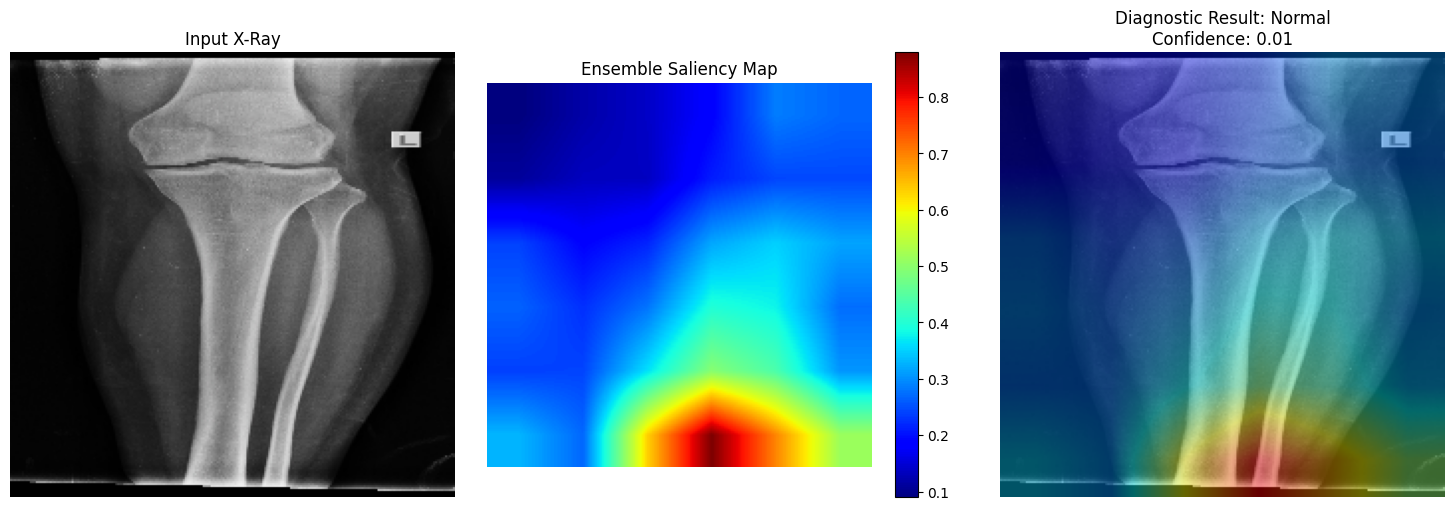

Saved: ensemble_result.png
Processing 5 ensemble model(s)...

--- Loading: cnn_model_0.h5 ---
  Last Conv Layer: conv2d_26
  Raw prediction: 0.5519
  Generating Grad-CAM...
  Generating Grad-CAM++...

--- Loading: cnn_model_1.h5 ---
  Last Conv Layer: conv2d_35
  Raw prediction: 0.0310
  Generating Grad-CAM...
  Generating Grad-CAM++...

--- Loading: cnn_model_2.h5 ---
  Last Conv Layer: conv2d_44
  Raw prediction: 0.0103
  Generating Grad-CAM...
  Generating Grad-CAM++...

--- Loading: cnn_model_3.h5 ---
  Last Conv Layer: conv2d_53
  Raw prediction: 0.0007
  Generating Grad-CAM...
  Generating Grad-CAM++...

--- Loading: cnn_model_4.h5 ---
  Last Conv Layer: conv2d_62
  Raw prediction: 0.2762
  Generating Grad-CAM...
  Generating Grad-CAM++...

✅ Done. Ensemble avg prediction: 0.1740


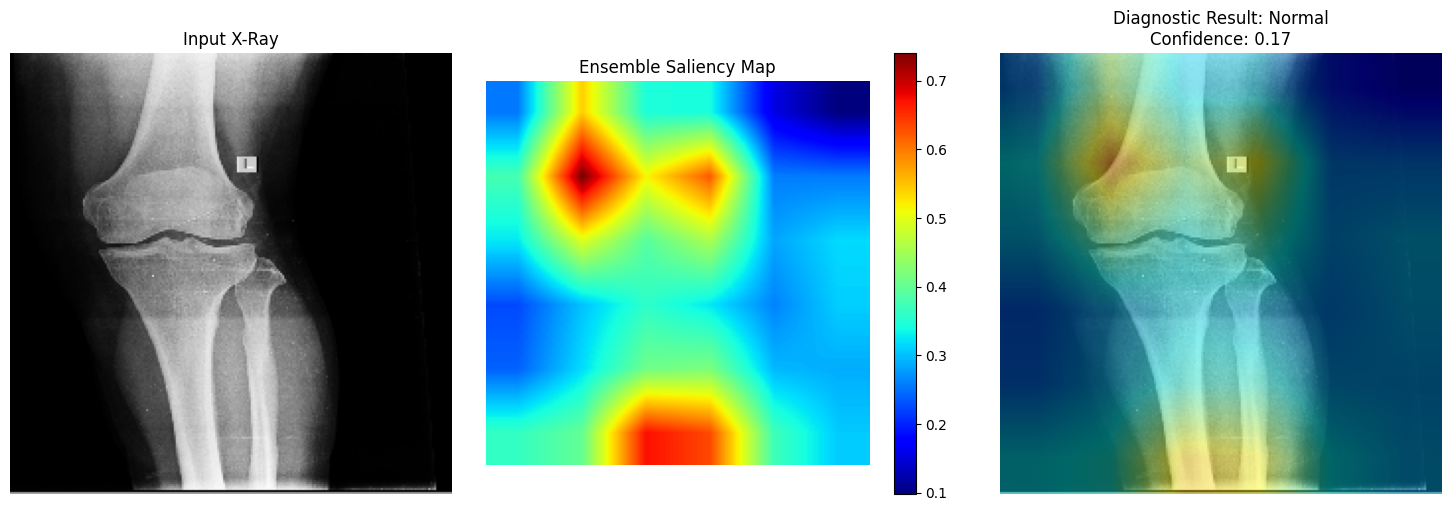

Saved: ensemble_result.png
Processing 5 ensemble model(s)...

--- Loading: cnn_model_0.h5 ---
  Last Conv Layer: conv2d_26
  Raw prediction: 0.0003
  Generating Grad-CAM...
  Generating Grad-CAM++...

--- Loading: cnn_model_1.h5 ---
  Last Conv Layer: conv2d_35
  Raw prediction: 0.0001
  Generating Grad-CAM...
  Generating Grad-CAM++...

--- Loading: cnn_model_2.h5 ---
  Last Conv Layer: conv2d_44
  Raw prediction: 0.0008
  Generating Grad-CAM...
  Generating Grad-CAM++...

--- Loading: cnn_model_3.h5 ---
  Last Conv Layer: conv2d_53
  Raw prediction: 0.0000
  Generating Grad-CAM...
  Generating Grad-CAM++...

--- Loading: cnn_model_4.h5 ---
  Last Conv Layer: conv2d_62
  Raw prediction: 0.0008
  Generating Grad-CAM...
  Generating Grad-CAM++...

✅ Done. Ensemble avg prediction: 0.0004


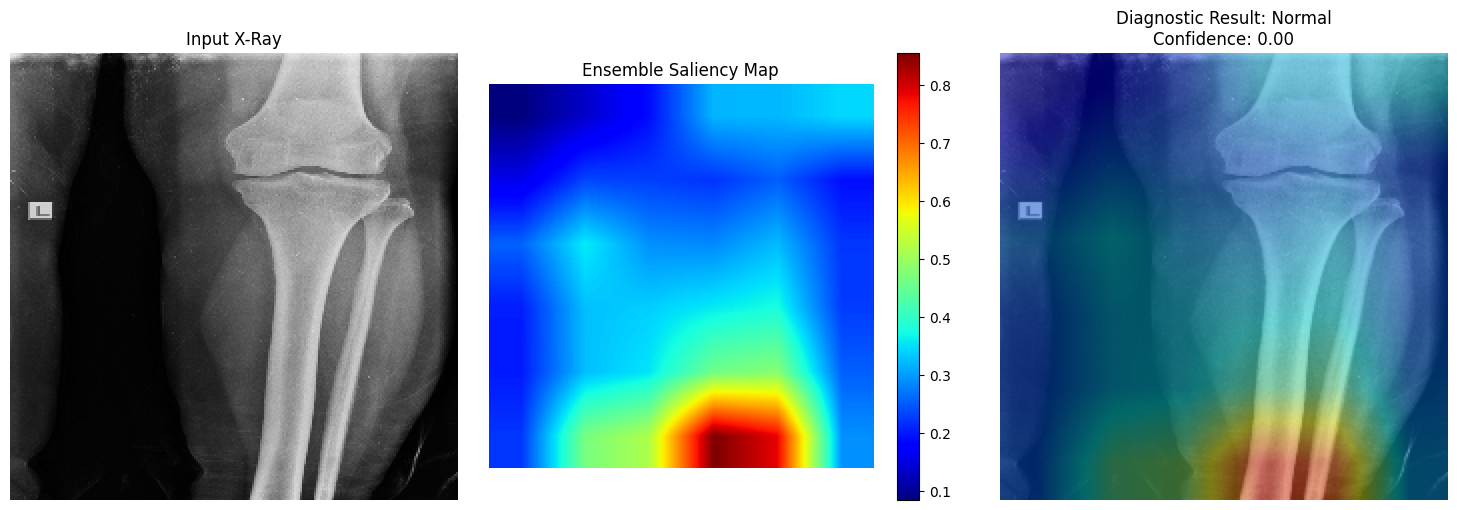

Saved: ensemble_result.png
Processing 5 ensemble model(s)...

--- Loading: cnn_model_0.h5 ---
  Last Conv Layer: conv2d_26
  Raw prediction: 0.0005
  Generating Grad-CAM...
  Generating Grad-CAM++...

--- Loading: cnn_model_1.h5 ---
  Last Conv Layer: conv2d_35
  Raw prediction: 0.0000
  Generating Grad-CAM...
  Generating Grad-CAM++...

--- Loading: cnn_model_2.h5 ---
  Last Conv Layer: conv2d_44
  Raw prediction: 0.0061
  Generating Grad-CAM...
  Generating Grad-CAM++...

--- Loading: cnn_model_3.h5 ---
  Last Conv Layer: conv2d_53
  Raw prediction: 0.0000
  Generating Grad-CAM...
  Generating Grad-CAM++...

--- Loading: cnn_model_4.h5 ---
  Last Conv Layer: conv2d_62
  Raw prediction: 0.0000
  Generating Grad-CAM...
  Generating Grad-CAM++...

✅ Done. Ensemble avg prediction: 0.0013


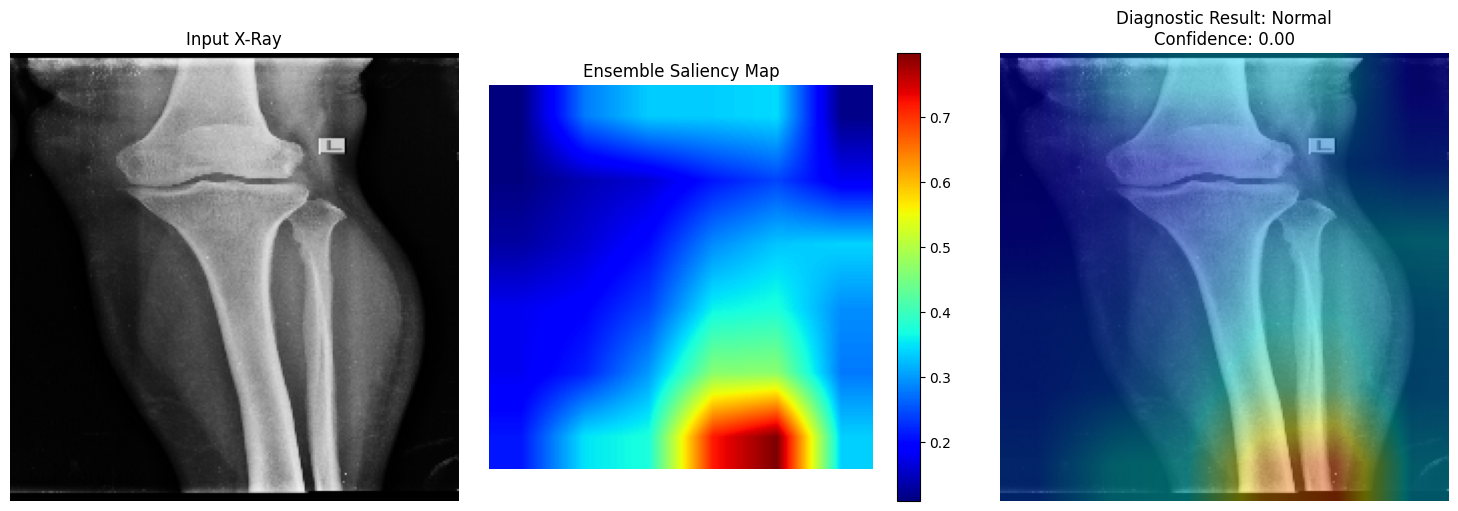

Saved: ensemble_result.png
Processing 5 ensemble model(s)...

--- Loading: cnn_model_0.h5 ---
  Last Conv Layer: conv2d_26
  Raw prediction: 0.1693
  Generating Grad-CAM...
  Generating Grad-CAM++...

--- Loading: cnn_model_1.h5 ---
  Last Conv Layer: conv2d_35
  Raw prediction: 0.0113
  Generating Grad-CAM...
  Generating Grad-CAM++...

--- Loading: cnn_model_2.h5 ---
  Last Conv Layer: conv2d_44
  Raw prediction: 0.0467
  Generating Grad-CAM...
  Generating Grad-CAM++...

--- Loading: cnn_model_3.h5 ---
  Last Conv Layer: conv2d_53
  Raw prediction: 0.0003
  Generating Grad-CAM...
  Generating Grad-CAM++...

--- Loading: cnn_model_4.h5 ---
  Last Conv Layer: conv2d_62
  Raw prediction: 0.0723
  Generating Grad-CAM...
  Generating Grad-CAM++...

✅ Done. Ensemble avg prediction: 0.0600


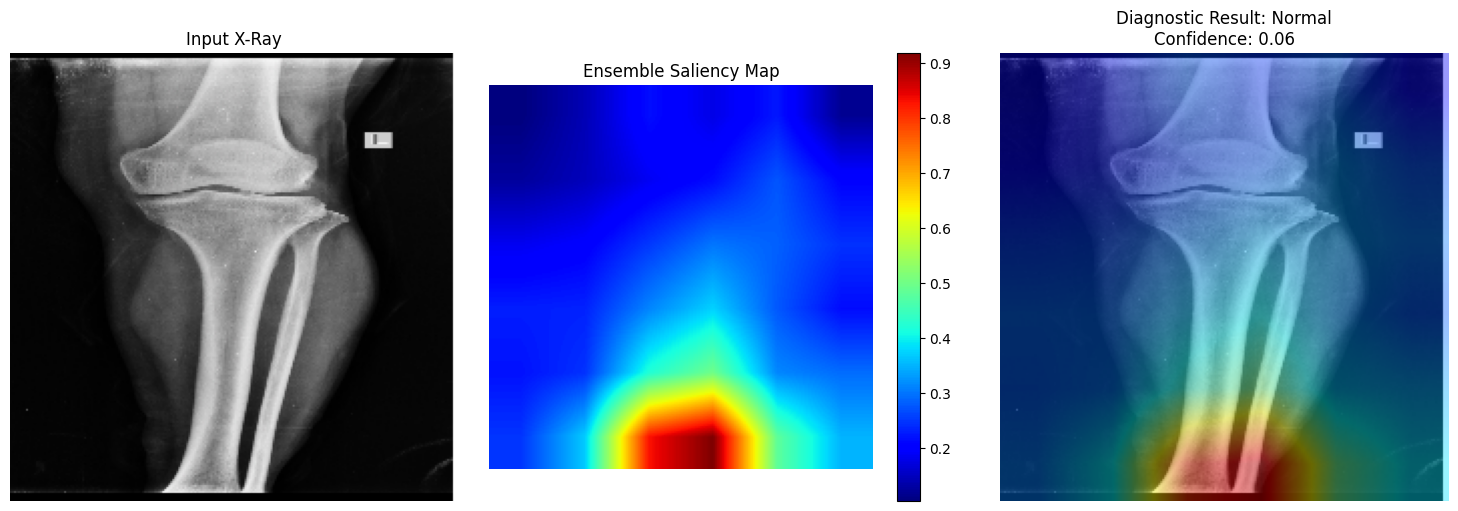

Saved: ensemble_result.png
Processing 5 ensemble model(s)...

--- Loading: cnn_model_0.h5 ---
  Last Conv Layer: conv2d_26
  Raw prediction: 0.0013
  Generating Grad-CAM...
  Generating Grad-CAM++...

--- Loading: cnn_model_1.h5 ---
  Last Conv Layer: conv2d_35
  Raw prediction: 0.0001
  Generating Grad-CAM...
  Generating Grad-CAM++...

--- Loading: cnn_model_2.h5 ---
  Last Conv Layer: conv2d_44
  Raw prediction: 0.0035
  Generating Grad-CAM...
  Generating Grad-CAM++...

--- Loading: cnn_model_3.h5 ---
  Last Conv Layer: conv2d_53
  Raw prediction: 0.0000
  Generating Grad-CAM...
  Generating Grad-CAM++...

--- Loading: cnn_model_4.h5 ---
  Last Conv Layer: conv2d_62
  Raw prediction: 0.0000
  Generating Grad-CAM...
  Generating Grad-CAM++...

✅ Done. Ensemble avg prediction: 0.0010


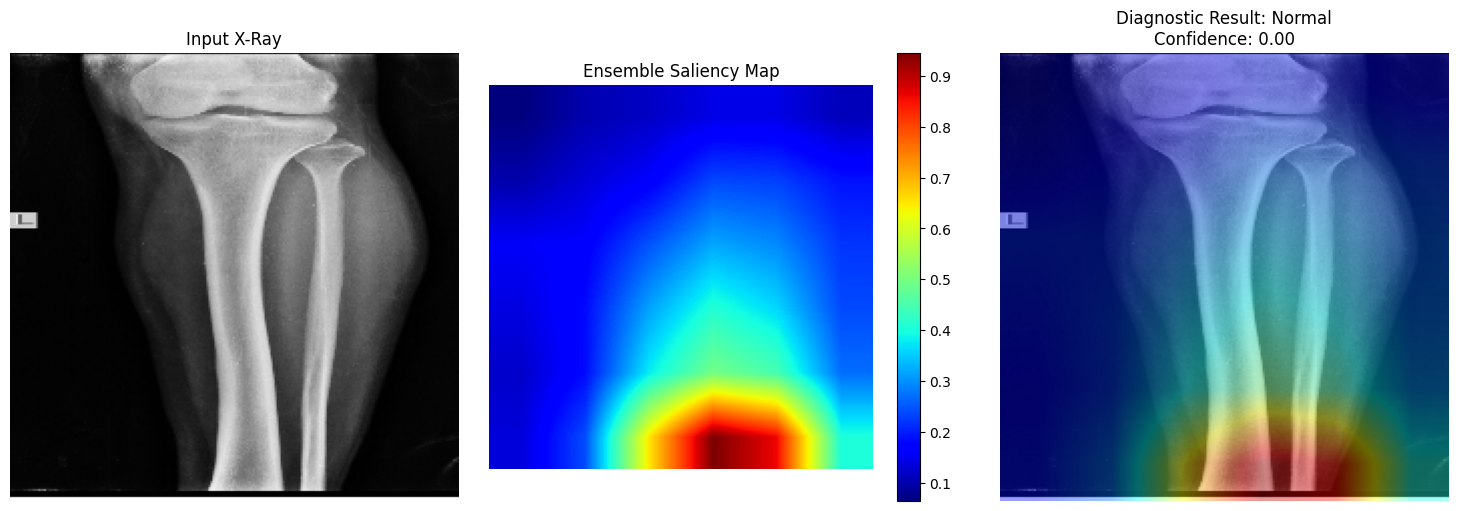

Saved: ensemble_result.png


In [5]:
model_files = [f"cnn_model_{i}.h5" for i in range(5)]

for i in range(10):
    j = i + 30

    test_image = rf"C:\Users\jaina\OneDrive\Desktop\Major P\OSP\dataset\normal\normal_{j:04d}.png"

    try:
        heatmap, img, pred = ensemble_explain(model_files, test_image)
        plot_result(heatmap, img, pred)

    except Exception as e:
        import traceback
        traceback.print_exc()
        print(f"\nError: {e}")